# Idea

This notebook's goal is feature engineering using:
- seaborn feature correlation heatmap,
- XGBoost feature importance method (*),
- SHAP analysis.

*This requires calling a diagnostic XGBoost model. The model will account for class imbalance \[95/5\]. The experiment will be saved using mlflow "simbox_fraud_detection" which will track the whole project.

---

### Imports

In [1]:
from pathlib import Path

import mlflow

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import shap
import xgboost as xgb

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

### Paths and MLflow

In [ ]:
PROJECT_ROOT = Path.cwd().parent.parent

DATA_PATH = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_PATH / "dvc" / "train_v2.parquet"

mlflow.set_tracking_uri(
    f"file:{PROJECT_ROOT / 'mlruns'}"
)

mlflow.set_experiment(
    "simbox_fraud_detection"
)

c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:c:\\Users\\ali.farhat\\Documents\\simbox-project\\mlruns/181740959998191728', creation_time=1781294983928, experiment_id='181740959998191728', last_update_time=1781294983928, lifecycle_stage='active', name='simbox_fraud_detection', tags={}, trace_location=None, workspace='default'>

### Load datasets

In [3]:
train_df = pd.read_parquet(TRAIN_PATH)

print(train_df.shape)

train_df.head()

# Features, Target and Groups

X = train_df.drop(
    columns=[
        "label",
        "msisdn",
        "profile_date"
    ],
    errors="ignore"
)

y = train_df["label"]

groups = train_df["msisdn"]

print(f"Features Shape: {X.shape}")

print(f"Fraud Profiles: {(y == 1).sum():,}")

print(f"Normal Profiles: {(y == 0).sum():,}")

(343040, 42)
Features Shape: (343040, 39)
Fraud Profiles: 19,725
Normal Profiles: 323,315


---
### Correlation Heatmap

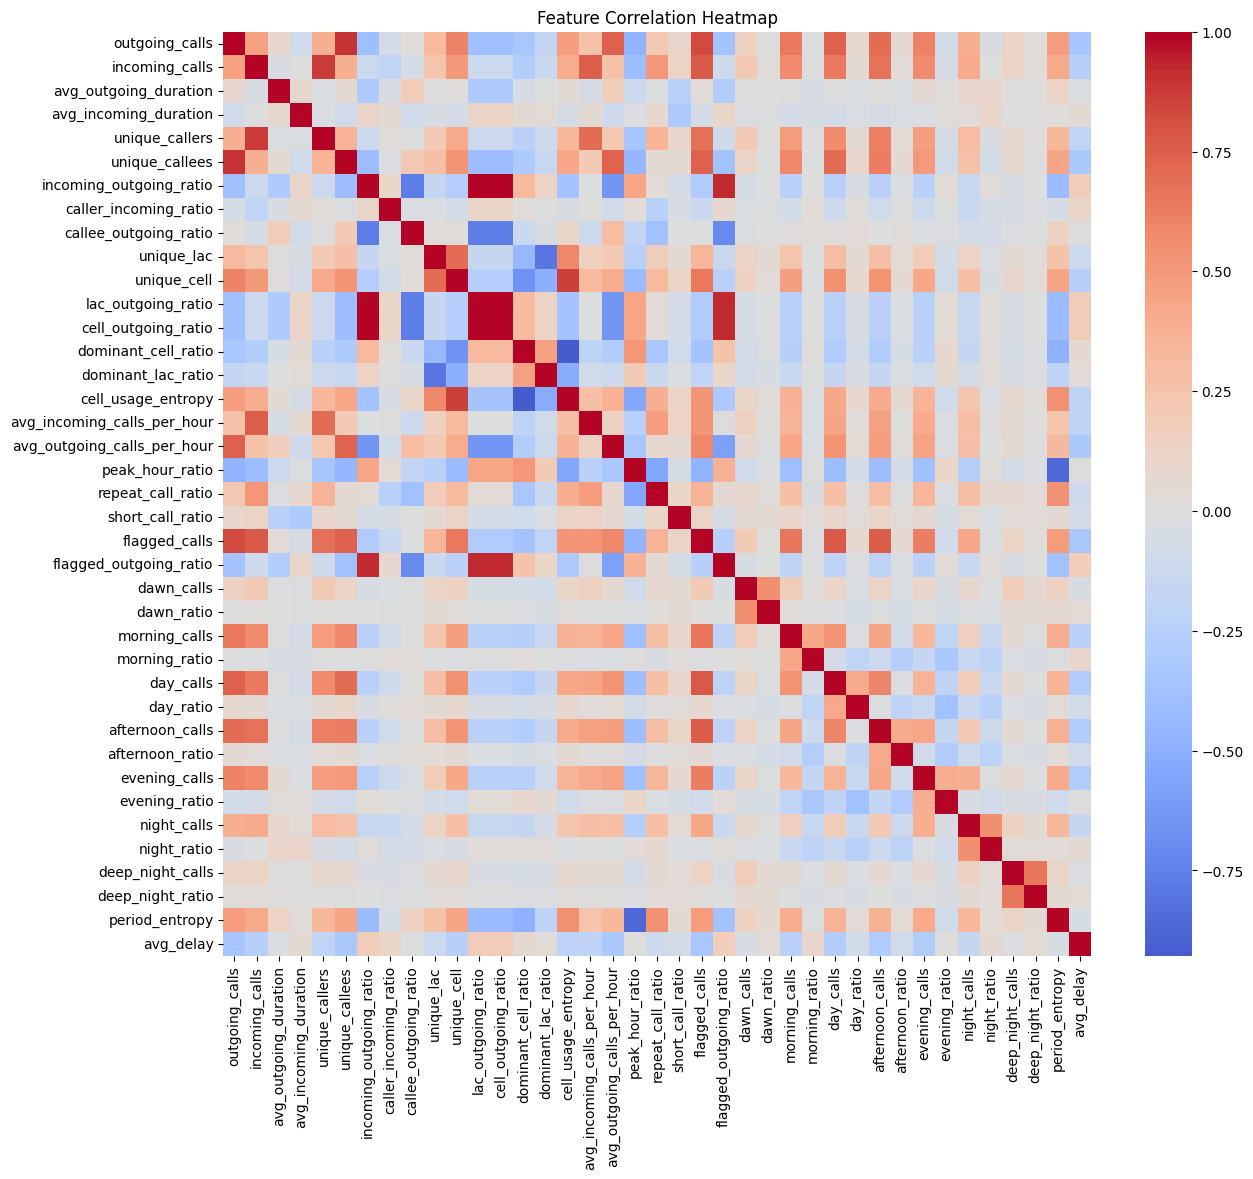

In [4]:
plt.figure(figsize=(14, 12))

corr = X.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

Correlation table

In [5]:
# Compute correlation matrix
corr_matrix = X.corr(numeric_only=True)

# Unstack to feature-pair format
corr_pairs = (
    corr_matrix
    .unstack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

# Remove self-correlations
corr_pairs = corr_pairs[
    corr_pairs["feature_1"] != corr_pairs["feature_2"]
]

# Take absolute value for ranking strength
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

# Sort by strongest correlations
corr_pairs = corr_pairs.sort_values(
    "abs_correlation",
    ascending=False
)

# Remove duplicate pairs (A-B vs B-A)
corr_pairs["sorted_pair"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["feature_1"], row["feature_2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates("sorted_pair")

# Final output
corr_pairs = corr_pairs.drop(columns=["sorted_pair"])

display(corr_pairs.head(30))

,feature_1,feature_2,correlation,abs_correlation
479,cell_outgoing_ratio,lac_outgoing_ratio,1.000000,1.000000
246,incoming_outgoing_ratio,cell_outgoing_ratio,1.000000,1.000000
435,lac_outgoing_ratio,incoming_outgoing_ratio,1.000000,1.000000
522,dominant_cell_ratio,cell_usage_entropy,-0.927998,0.927998
256,incoming_outgoing_ratio,flagged_outgoing_ratio,0.921099,0.921099
870,flagged_outgoing_ratio,cell_outgoing_ratio,0.921099,0.921099
451,lac_outgoing_ratio,flagged_outgoing_ratio,0.921099,0.921099
5,outgoing_calls,unique_callees,0.894803,0.894803
157,unique_callers,incoming_calls,0.879338,0.879338
739,peak_hour_ratio,period_entropy,-0.863679,0.863679


---
### XGBoost feature importance

Set up baseline XGBoost and MLflow

In [ ]:
fraud_count = (y == 1).sum()

normal_count = (y == 0).sum()

scale_pos_weight = (normal_count / fraud_count)

dtrain = xgb.DMatrix(
    X,
    label=y
)

params = {
    "objective": "binary:logistic",
    "eval_metric": ["aucpr", "auc"],
    "max_depth": 6,
    "eta": 0.05,
    "scale_pos_weight": scale_pos_weight,
    "seed": 42
}

with mlflow.start_run(
    run_name="exploratory_feature_analysis_v2"
):

    mlflow.set_tag(
        "dataset_version",
        "v2"
    )

    mlflow.set_tag(
        "run_type",
        "exploratory_analysis"
    )

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=200
    )

    pred_proba = model.predict(dtrain)

    pr_auc = (
        average_precision_score(y, pred_proba)
    )

    roc_auc = (
        roc_auc_score(y, pred_proba)
    )

    mlflow.log_metric(
        "pr_auc",
        pr_auc
    )

    mlflow.log_metric(
        "roc_auc",
        roc_auc
    )

print(f"PR-AUC: {pr_auc:.6f}")

print(f"ROC-AUC: {roc_auc:.6f}")

print(
    "\nNote: Metrics are optimistic because "
    "the model is evaluated on the same "
    "dataset used for training."
)

PR-AUC: 0.454143
ROC-AUC: 0.883480

Note: Metrics are optimistic because the model is evaluated on the same dataset used for training.


Compute feature importance

In [10]:
gain_scores = model.get_score(
    importance_type="gain"
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": [
        gain_scores.get(feature, 0)
        for feature in X.columns
    ]
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

display(importance_df.head(30))

,feature,importance
19,repeat_call_ratio,1720.428711
22,flagged_outgoing_ratio,1425.705933
6,incoming_outgoing_ratio,620.054810
1,incoming_calls,605.840027
5,unique_callees,580.852783
2,avg_outgoing_duration,396.640625
21,flagged_calls,215.395065
20,short_call_ratio,157.749176
9,unique_lac,111.695267
3,avg_incoming_duration,106.872391


Feature importance plot

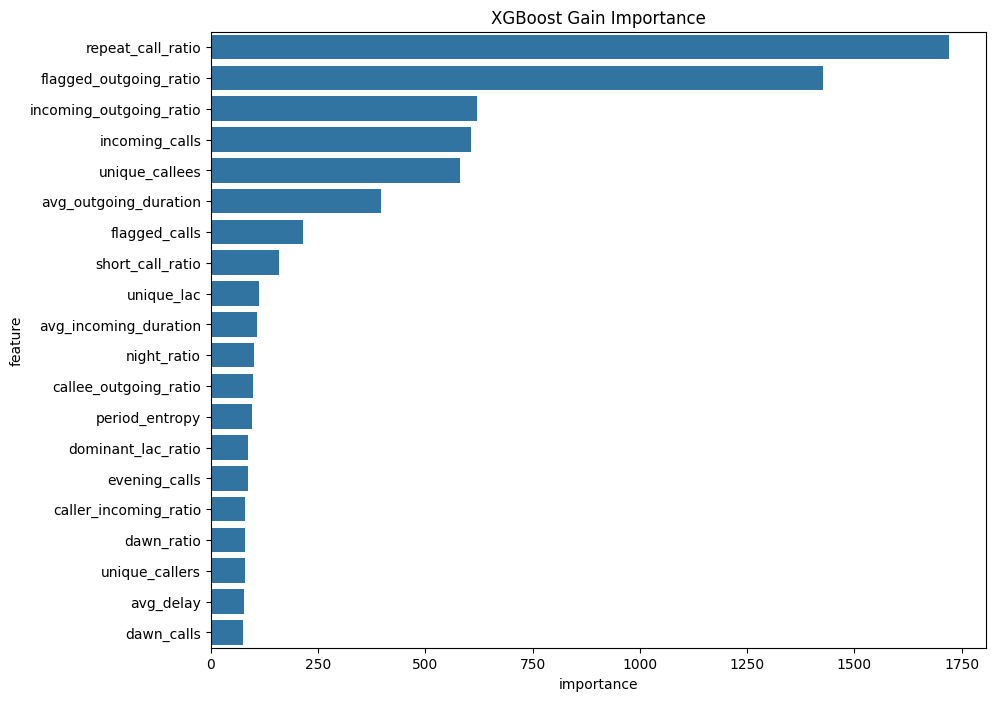

In [11]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature"
)

plt.title(
    "XGBoost Gain Importance"
)

plt.show()

---
### SHAP analysis

In [12]:
sample_size = min(
    5000,
    len(X)
)

X_sample = X.sample(
    sample_size,
    random_state=42
)

explainer = shap.TreeExplainer(
    model
)

shap_values = explainer.shap_values(
    X_sample
)

Summary plot

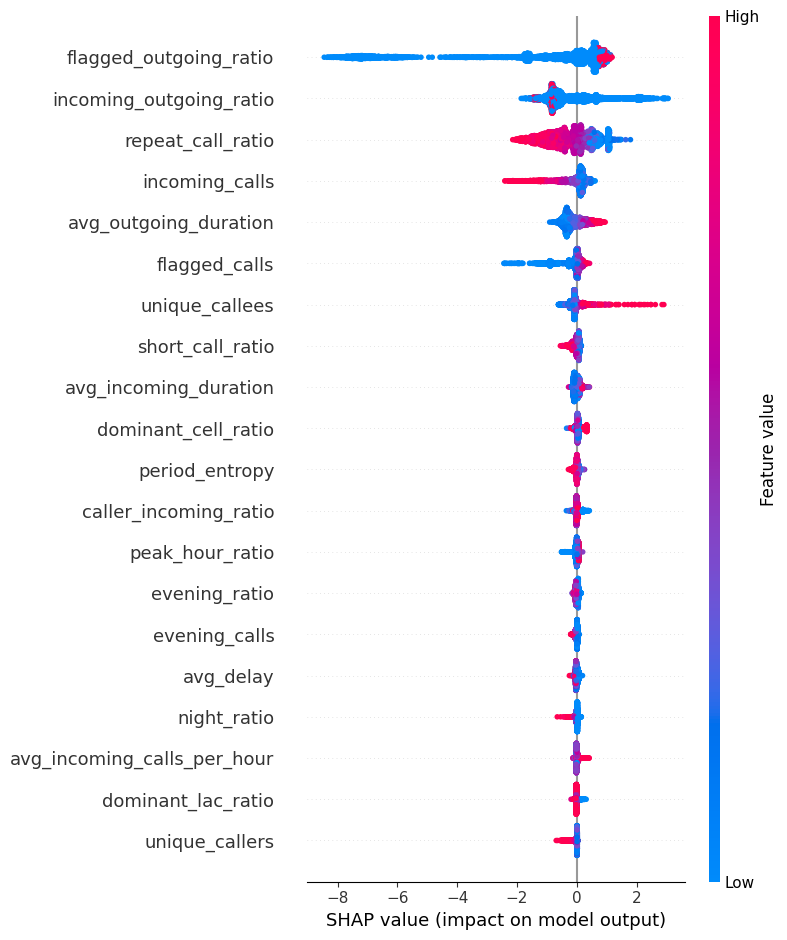

In [13]:
shap.summary_plot(
    shap_values,
    X_sample
)

Bar plot

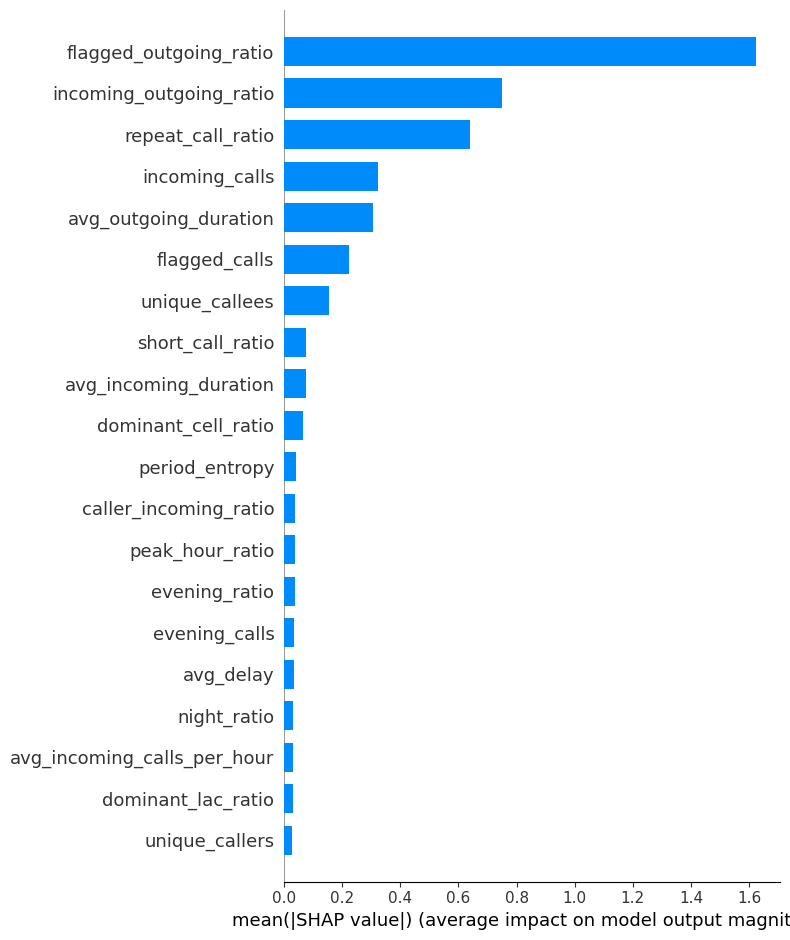

In [14]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

---
### Feature Ablation

Ablation of sets, groups, or families of features to evaluate model performance without them.

<br> Ablation Sets </br>

In [4]:
# ====================================
# Ablation Sets
# ====================================

sweetviz_features = [
    "outgoing_calls",
    "avg_incoming_duration",
    "avg_outgoing_duration",
    "unique_callees",
    "caller_incoming_ratio",
    "callee_outgoing_ratio",
    "cell_usage_entropy",
    "avg_outgoing_calls_per_hour",
    "repeat_call_ratio",
    "short_call_ratio",
    "flagged_calls",
    "day_calls",
    "day_ratio",
    "afternoon_calls",
    "afternoon_ratio",
    "period_entropy",
    "peak_hour_ratio",
    "avg_delay"
]

xgb_shap_features = [
    "repeat_call_ratio",
    "flagged_outgoing_ratio",
    "incoming_outgoing_ratio",
    "incoming_calls",
    "unique_callees",
    "avg_outgoing_duration",
    "flagged_calls",
    "short_call_ratio"
]

correlation_features = [
    "dawn_ratio",
    "deep_night_ratio",
    "morning_ratio",
    "day_ratio",
    "afternoon_ratio",
    "evening_ratio",
    "night_ratio",
    "avg_incoming_duration",
    "avg_outgoing_duration",
    "caller_incoming_ratio",
    "dominant_lac_ratio",
    "short_call_ratio",
    "cell_usage_entropy",
    "period_entropy",
    "flagged_outgoing_ratio",
    "avg_incoming_calls_per_hour",
    "avg_outgoing_calls_per_hour",
    "unique_callers",
    "unique_callees",
    "incoming_outgoing_ratio"
]

all_features = list(X.columns)

ablation_sets = {

    # ====================================
    # Baseline
    # ====================================

    "baseline": [],

    # ====================================
    # Feature Family Tests
    # ====================================

    "drop_flagged_calls": [
        "flagged_calls"
    ],

    "drop_period_entropy": [
        "period_entropy"
    ],

    "drop_cell_entropy": [
        "cell_usage_entropy"
    ],

    "drop_mobility_ratios": [
        "lac_outgoing_ratio",
        "cell_outgoing_ratio"
    ],

    "drop_graph_ratios": [
        "caller_incoming_ratio",
        "callee_outgoing_ratio"
    ],

    "drop_ratio_keep_counts": [
        "incoming_outgoing_ratio"
    ],

    # ====================================
    # Entropy Representation Tests
    # ====================================

    "entropy_only_mobility": [
        "unique_lac",
        "unique_cell",
        "lac_outgoing_ratio",
        "cell_outgoing_ratio",
        "dominant_lac_ratio",
        "dominant_cell_ratio"
    ],

    "entropy_only_periods": [
        "dawn_calls",
        "morning_calls",
        "day_calls",
        "afternoon_calls",
        "evening_calls",
        "night_calls",
        "deep_night_calls",
        "dawn_ratio",
        "morning_ratio",
        "day_ratio",
        "afternoon_ratio",
        "evening_ratio",
        "night_ratio",
        "deep_night_ratio"
    ],

    # ====================================
    # Selection Method Comparison
    # ====================================

    "sweetviz_selected": [
        feature
        for feature in all_features
        if feature not in sweetviz_features
    ],

    "xgb_shap_selected": [
        feature
        for feature in all_features
        if feature not in xgb_shap_features
    ],

    "correlation_selected": [
        feature
        for feature in all_features
        if feature not in correlation_features
    ]
}

Feature Ablation Evaluation

In [5]:
from sklearn.model_selection import (
    StratifiedGroupKFold
)

results = []

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for run_name, dropped_features in ablation_sets.items():

    current_X = X.drop(
        columns=dropped_features,
        errors="ignore"
    )

    fold_pr_auc = []
    fold_roc_auc = []

    with mlflow.start_run(
        run_name=f"ablation_{run_name}"
    ):

        mlflow.set_tag(
            "dataset_version",
            "v2"
        )

        mlflow.set_tag(
            "run_type",
            "ablation"
        )

        mlflow.log_param(
            "removed_features",
            ",".join(dropped_features)
        )

        mlflow.log_param(
            "remaining_features",
            current_X.shape[1]
        )

        for fold_id, (train_idx, val_idx) in enumerate(
            cv.split(
                current_X,
                y,
                groups
            ),
            start=1
        ):

            X_train = current_X.iloc[train_idx]
            X_val = current_X.iloc[val_idx]

            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx]

            fraud_count = (y_train == 1).sum()
            normal_count = (y_train == 0).sum()

            scale_pos_weight = (
                normal_count
                /
                fraud_count
            )

            dtrain = xgb.DMatrix(
                X_train,
                label=y_train
            )

            dval = xgb.DMatrix(
                X_val,
                label=y_val
            )

            params = {
                "objective": "binary:logistic",
                "eval_metric": ["aucpr", "auc"],
                "max_depth": 6,
                "eta": 0.05,
                "scale_pos_weight": scale_pos_weight,
                "seed": 42
            }

            model = xgb.train(
                params=params,
                dtrain=dtrain,
                num_boost_round=200
            )

            pred_proba = model.predict(
                dval
            )

            pr_auc = average_precision_score(
                y_val,
                pred_proba
            )

            roc_auc = roc_auc_score(
                y_val,
                pred_proba
            )

            fold_pr_auc.append(pr_auc)
            fold_roc_auc.append(roc_auc)

        mean_pr_auc = np.mean(fold_pr_auc)
        std_pr_auc = np.std(fold_pr_auc)

        mean_roc_auc = np.mean(fold_roc_auc)
        std_roc_auc = np.std(fold_roc_auc)

        mlflow.log_metric(
            "pr_auc_mean",
            mean_pr_auc
        )

        mlflow.log_metric(
            "pr_auc_std",
            std_pr_auc
        )

        mlflow.log_metric(
            "roc_auc_mean",
            mean_roc_auc
        )

        mlflow.log_metric(
            "roc_auc_std",
            std_roc_auc
        )

        results.append({
            "run_name": run_name,
            "removed_features": dropped_features,
            "features_remaining": current_X.shape[1],
            "pr_auc_mean": mean_pr_auc,
            "pr_auc_std": std_pr_auc,
            "roc_auc_mean": mean_roc_auc,
            "roc_auc_std": std_roc_auc
        })

results_df = (
    pd.DataFrame(results)
    .sort_values(
        "pr_auc_mean",
        ascending=False
    )
)

display(results_df)

2026/06/25 19:27:39 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



,run_name,removed_features,features_remaining,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std
3,drop_cell_entropy,[cell_usage_entropy],38,0.430376,0.011732,0.865850,0.003350
4,drop_mobility_ratios,"[lac_outgoing_ratio, cell_outgoing_ratio]",37,0.430229,0.012085,0.865607,0.003315
2,drop_period_entropy,[period_entropy],38,0.430134,0.011811,0.865571,0.003445
7,entropy_only_mobility,"[unique_lac, unique_cell, lac_outgoing_ratio, ...",33,0.430092,0.011993,0.865641,0.003367
0,baseline,[],39,0.430091,0.012152,0.865611,0.003315
8,entropy_only_periods,"[dawn_calls, morning_calls, day_calls, afterno...",25,0.429966,0.012116,0.865831,0.003333
5,drop_graph_ratios,"[caller_incoming_ratio, callee_outgoing_ratio]",37,0.429946,0.011931,0.865543,0.003389
1,drop_flagged_calls,[flagged_calls],38,0.429348,0.012339,0.864266,0.003572
10,xgb_shap_selected,"[outgoing_calls, avg_incoming_duration, unique...",8,0.428550,0.011906,0.865900,0.003060
6,drop_ratio_keep_counts,[incoming_outgoing_ratio],38,0.424365,0.011758,0.858110,0.003613


### Analysis

🟢 Tier 1 — CORE FEATURES (must keep)

- flagged_calls
- flagged_outgoing_ratio
- incoming_outgoing_ratio
- incoming_calls
- unique_callees
- avg_outgoing_duration
- short_call_ratio
- repeat_call_ratio

🟡 Tier 2 — SUPPORT FEATURES (useful but not critical)
- unique_callers
- avg_incoming_duration
- avg_outgoing_calls_per_hour
- peak_hour_ratio
- cell_usage_entropy (optional)
- period_entropy (optional)

🔴 Tier 3 — REDUNDANT / DROP CANDIDATES
- lac_outgoing_ratio
- cell_outgoing_ratio
- caller_incoming_ratio
- callee_outgoing_ratio
- most raw day/time split features (some redundancy with entropy)

---
### Feature Ablation - Wave 2: Feature set compression comparison

In [6]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ====================================
# Feature Sets (explicitly defined)
# ====================================

best_shap_features = [
    "repeat_call_ratio",
    "flagged_outgoing_ratio",
    "incoming_outgoing_ratio",
    "incoming_calls",
    "unique_callees",
    "avg_outgoing_duration",
    "flagged_calls",
    "short_call_ratio"
]

tier_1_features_only = [
    "flagged_calls",
    "flagged_outgoing_ratio",
    "incoming_outgoing_ratio",
    "incoming_calls",
    "unique_callees",
    "avg_outgoing_duration",
    "short_call_ratio",
    "repeat_call_ratio"
]

tier_1_and_2_features = [
    # Tier 1
    "flagged_calls",
    "flagged_outgoing_ratio",
    "incoming_outgoing_ratio",
    "incoming_calls",
    "unique_callees",
    "avg_outgoing_duration",
    "short_call_ratio",
    "repeat_call_ratio",

    # Tier 2
    "unique_callers",
    "avg_incoming_duration",
    "avg_outgoing_calls_per_hour",
    "peak_hour_ratio"
]

# ====================================
# Cell + Period entropy correlated features
# ====================================

cell_period_entropy = [
    # mobility-related
    "unique_cell",
    "unique_lac",
    "lac_outgoing_ratio",
    "cell_outgoing_ratio",
    "dominant_cell_ratio",
    "dominant_lac_ratio",

    # period-related
    "dawn_calls",
    "morning_calls",
    "day_calls",
    "afternoon_calls",
    "evening_calls",
    "night_calls",
    "deep_night_calls",

    "dawn_ratio",
    "morning_ratio",
    "day_ratio",
    "afternoon_ratio",
    "evening_ratio",
    "night_ratio",
    "deep_night_ratio"
]

feature_sets = {

    "best_shap_features": best_shap_features,

    "tier_1_only": tier_1_features_only,

    "tier_1_and_2": tier_1_and_2_features,

    "cell_period_entropy_drop": cell_period_entropy
}

# ====================================
# MLflow dataset
# ====================================

train_dataset = mlflow.data.from_pandas(
    train_df,
    source=str(TRAIN_PATH),
    name="train_v2"
)

results = []

# ====================================
# Evaluation loop
# ====================================

for run_name, selected_features in feature_sets.items():

    X_sel = X[selected_features].copy()

    fold_pr_auc = []
    fold_roc_auc = []

    with mlflow.start_run(run_name=f"wave2_{run_name}"):

        mlflow.log_input(
            train_dataset,
            context="training"
        )

        mlflow.set_tag("dataset_version", "v2")
        mlflow.set_tag("experiment_stage", "wave2_feature_compression")

        mlflow.log_param(
            "num_features",
            len(selected_features)
        )

        for train_idx, val_idx in cv.split(X_sel, y):

            X_train = X_sel.iloc[train_idx]
            X_val = X_sel.iloc[val_idx]

            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx]

            spw = (y_train == 0).sum() / (y_train == 1).sum()

            dtrain = xgb.DMatrix(X_train, label=y_train)
            dval = xgb.DMatrix(X_val, label=y_val)

            params = {
                "objective": "binary:logistic",
                "eval_metric": ["aucpr", "auc"],
                "max_depth": 6,
                "eta": 0.05,
                "scale_pos_weight": spw,
                "seed": 42
            }

            model = xgb.train(
                params=params,
                dtrain=dtrain,
                num_boost_round=200
            )

            preds = model.predict(dval)

            pr_auc = average_precision_score(y_val, preds)
            roc_auc = roc_auc_score(y_val, preds)

            fold_pr_auc.append(pr_auc)
            fold_roc_auc.append(roc_auc)

        mlflow.log_metric("pr_auc_mean", np.mean(fold_pr_auc))
        mlflow.log_metric("pr_auc_std", np.std(fold_pr_auc))
        mlflow.log_metric("roc_auc_mean", np.mean(fold_roc_auc))
        mlflow.log_metric("roc_auc_std", np.std(fold_roc_auc))

        results.append({
            "run": run_name,
            "num_features": len(selected_features),
            "pr_auc_mean": np.mean(fold_pr_auc),
            "roc_auc_mean": np.mean(fold_roc_auc)
        })

results_df = pd.DataFrame(results).sort_values(
    "pr_auc_mean",
    ascending=False
)

display(results_df)

c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling 

,run,num_features,pr_auc_mean,roc_auc_mean
2,tier_1_and_2,12,0.429946,0.866271
1,tier_1_only,8,0.429415,0.866251
0,best_shap_features,8,0.429412,0.866251
3,cell_period_entropy_drop,20,0.217701,0.738663


Note:
- tier_1_and_2 / baseline = 99.97% pr_auc
- tier_1_and_2 / highest  = 99.90% pr_auc

---
## Finalizing feature choice: dataset_v3
This dataset is made of tier_1_and_2 features.


In [7]:
#========================
# New paths
#========================

TRAIN_V2_PATH = DATA_PATH / "dvc" / "train_v2.parquet"
TEST_V2_PATH = DATA_PATH / "dvc" / "test_v2.parquet"

TRAIN_V3_PATH = DATA_PATH / "dvc" / "train_v3.parquet"
TEST_V3_PATH = DATA_PATH / "dvc" / "test_v3.parquet"


#========================
# Load datasets
#========================

train_df = pd.read_parquet(TRAIN_V2_PATH)
test_df = pd.read_parquet(TEST_V2_PATH)

print(train_df.shape)
print(test_df.shape)


#========================
# Final feature set
#========================

FINAL_FEATURES = [
    "repeat_call_ratio",
    "flagged_outgoing_ratio",
    "incoming_outgoing_ratio",
    "incoming_calls",
    "unique_callees",
    "avg_outgoing_duration",
    "flagged_calls",
    "short_call_ratio",
    "unique_callers",
    "avg_incoming_duration",
    "avg_outgoing_calls_per_hour",
    "peak_hour_ratio"
]

METADATA_COLUMNS = [
    "msisdn",
    "profile_date",
    "label"
]

KEEP_COLUMNS = METADATA_COLUMNS + FINAL_FEATURES


#========================
# Create v3 datasets
#========================

train_v3 = train_df[KEEP_COLUMNS].copy()
test_v3 = test_df[KEEP_COLUMNS].copy()

print(train_v3.shape)
print(test_v3.shape)

display(train_v3.head())


#========================
# Verify datasets
#========================

print("Train v3")
print(f"Rows: {len(train_v3):,}")
print(f"Features: {len(FINAL_FEATURES)}")
print(f"Columns: {train_v3.shape[1]}")
print()

print("Test v3")
print(f"Rows: {len(test_v3):,}")
print(f"Features: {len(FINAL_FEATURES)}")
print(f"Columns: {test_v3.shape[1]}")


#========================
# Save datasets
#========================

train_v3.to_parquet(
    TRAIN_V3_PATH,
    index=False
)

test_v3.to_parquet(
    TEST_V3_PATH,
    index=False
)

print(f"Saved: {TRAIN_V3_PATH.name}")
print(f"Saved: {TEST_V3_PATH.name}")

(343040, 42)
(85760, 42)
(343040, 15)
(85760, 15)


,msisdn,profile_date,label,repeat_call_ratio,flagged_outgoing_ratio,incoming_outgoing_ratio,incoming_calls,unique_callees,avg_outgoing_duration,flagged_calls,short_call_ratio,unique_callers,avg_incoming_duration,avg_outgoing_calls_per_hour,peak_hour_ratio
0,22362444330,2022-11-01,0,0.800000,999999.0,999999.0,5,0,0.0,5,0.000000,4,136.200000,0.000000,0.4
1,22667898029,2022-11-01,0,0.000000,999999.0,999999.0,1,0,0.0,1,0.000000,1,90.000000,0.000000,1.0
2,22995468560,2022-11-01,0,0.500000,999999.0,999999.0,2,0,0.0,2,0.500000,1,38.000000,0.000000,1.0
3,2250101000087,2022-11-01,0,0.400000,2.5,1.5,3,2,57.5,5,0.600000,3,23.666667,2.000000,0.6
4,2250101000108,2022-11-01,0,0.166667,1.2,0.2,2,9,329.1,12,0.333333,2,40.000000,3.333333,0.5


Train v3
Rows: 343,040
Features: 12
Columns: 15

Test v3
Rows: 85,760
Features: 12
Columns: 15
Saved: train_v3.parquet
Saved: test_v3.parquet


### Version Metadata

In [8]:
print("=" * 60)
print("Dataset Version: v3")
print("=" * 60)

print(f"Source train dataset : {TRAIN_V2_PATH.name}")
print(f"Source test dataset  : {TEST_V2_PATH.name}")

print()

print(f"Train rows           : {len(train_v3):,}")
print(f"Test rows            : {len(test_v3):,}")

print()

print(f"Model features       : {len(FINAL_FEATURES)}")
print(f"Metadata columns     : {len(METADATA_COLUMNS)}")
print(f"Total columns        : {train_v3.shape[1]}")

print()

print("Final Features:")
for feature in FINAL_FEATURES:
    print(f"  • {feature}")

Dataset Version: v3
Source train dataset : train_v2.parquet
Source test dataset  : test_v2.parquet

Train rows           : 343,040
Test rows            : 85,760

Model features       : 12
Metadata columns     : 3
Total columns        : 15

Final Features:
  • repeat_call_ratio
  • flagged_outgoing_ratio
  • incoming_outgoing_ratio
  • incoming_calls
  • unique_callees
  • avg_outgoing_duration
  • flagged_calls
  • short_call_ratio
  • unique_callers
  • avg_incoming_duration
  • avg_outgoing_calls_per_hour
  • peak_hour_ratio
